<a href="https://colab.research.google.com/github/divyadharshini-1306/Mutual-Fund-Style-Drifter/blob/main/style_drift_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 3 — Feature Engineering & ML
**Input:** holdings_with_cap.csv (22,461 rows, 12 columns)  
**Output:** K-Means clusters, PCA visualisation, drift scores per fund  
**Techniques:** Feature matrix construction · K-Means (K=3) · PCA · Anomaly scoring

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/StyleDrift_Project"

# Load the enriched dataset from Phase 2
holdings = pd.read_csv(f"{BASE}/processed/holdings_with_cap.csv")
holdings["statement_date"] = pd.to_datetime(holdings["statement_date"], format="mixed", dayfirst=True)

print(f"Shape: {holdings.shape}")
print(f"Funds: {holdings['scheme_name'].nunique()}")
print(f"Date range: {holdings['statement_date'].min().date()} → {holdings['statement_date'].max().date()}")
print(f"Cap categories: {holdings['cap_category'].value_counts().to_dict()}")

Mounted at /content/drive
Shape: (22461, 12)
Funds: 12
Date range: 2023-01-31 → 2026-05-31
Cap categories: {'Small Cap': 8126, 'Mid Cap': 7030, 'Large Cap': 6632, 'Unclassified': 673}


### P3-2 — Build Monthly Feature Matrix
One row = one fund × one month. Features describe the fund's actual behaviour that month.

In [2]:
# Filter out Unclassified rows before building features
# Bonds/ETFs/foreign stocks would distort the cap mix percentages
holdings_clean = holdings[holdings["cap_category"] != "Unclassified"].copy()
print(f"Rows after removing Unclassified: {len(holdings_clean)} (removed {len(holdings) - len(holdings_clean)})")

# ── Feature 1, 2, 3: Cap mix per fund per month ──────────────────────────────
# For each fund-month, what % of total AUM is in Large / Mid / Small cap stocks?
# pct_to_aum is already the weight of each stock in the fund
# We sum these weights by cap category per fund-month

cap_mix = (
    holdings_clean
    .groupby(["scheme_name", "statement_date", "cap_category"])["pct_to_aum"]
    .sum()
    .unstack(fill_value=0)   # cap_category becomes columns
    .reset_index()
)

# Rename columns cleanly
cap_mix.columns.name = None
cap_mix = cap_mix.rename(columns={
    "Large Cap": "pct_large_cap",
    "Mid Cap":   "pct_mid_cap",
    "Small Cap": "pct_small_cap"
})

# Make sure all three columns exist even if a fund has zero of one type
for col in ["pct_large_cap", "pct_mid_cap", "pct_small_cap"]:
    if col not in cap_mix.columns:
        cap_mix[col] = 0.0

print(f"\nCap mix shape: {cap_mix.shape}")
print(cap_mix.head(3).to_string())

Rows after removing Unclassified: 21788 (removed 673)

Cap mix shape: (354, 5)
           scheme_name statement_date  pct_large_cap  pct_mid_cap  pct_small_cap
0  Kotak Flexicap Fund     2024-11-30          70.39        22.49           5.61
1  Kotak Flexicap Fund     2024-12-31          69.14        23.10           5.85
2  Kotak Flexicap Fund     2025-01-31          72.60        19.43           5.82


In [3]:
# ── Feature 4: Top-10 holding concentration ───────────────────────────────────
# How much of the fund's AUM is concentrated in its top 10 stocks?
# High concentration = more idiosyncratic risk, less diversified

top10_conc = (
    holdings_clean
    .sort_values("pct_to_aum", ascending=False)
    .groupby(["scheme_name", "statement_date"])
    .apply(lambda x: x.nlargest(10, "pct_to_aum")["pct_to_aum"].sum())
    .reset_index()
    .rename(columns={0: "top10_concentration"})
)

print(f"Top-10 concentration shape: {top10_conc.shape}")
print(top10_conc.head(3).to_string())

# ── Feature 5: Sector concentration (Herfindahl index) ────────────────────────
# Measures how spread out or concentrated the fund is across sectors
# HHI = sum of squared sector weights — higher = more concentrated in fewer sectors
# Range: near 0 (perfectly spread) → 10000 (100% in one sector)

sector_hhi = (
    holdings_clean
    .groupby(["scheme_name", "statement_date", "sector"])["pct_to_aum"]
    .sum()
    .reset_index()
)
sector_hhi["weight_sq"] = sector_hhi["pct_to_aum"] ** 2
sector_hhi = (
    sector_hhi
    .groupby(["scheme_name", "statement_date"])["weight_sq"]
    .sum()
    .reset_index()
    .rename(columns={"weight_sq": "sector_hhi"})
)

print(f"\nSector HHI shape: {sector_hhi.shape}")
print(sector_hhi.head(3).to_string())

Top-10 concentration shape: (354, 3)
           scheme_name statement_date  top10_concentration
0  Kotak Flexicap Fund     2024-11-30                43.90
1  Kotak Flexicap Fund     2024-12-31                43.84
2  Kotak Flexicap Fund     2025-01-31                44.49

Sector HHI shape: (354, 3)
           scheme_name statement_date  sector_hhi
0  Kotak Flexicap Fund     2024-11-30    841.4363
1  Kotak Flexicap Fund     2024-12-31    829.1283
2  Kotak Flexicap Fund     2025-01-31    839.0451


/tmp/ipykernel_11753/1911271414.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, "pct_to_aum")["pct_to_aum"].sum())


In [4]:
# ── Merge all 5 features into one feature matrix ─────────────────────────────
feature_matrix = cap_mix.copy()

feature_matrix = feature_matrix.merge(top10_conc, on=["scheme_name", "statement_date"], how="left")
feature_matrix = feature_matrix.merge(sector_hhi,  on=["scheme_name", "statement_date"], how="left")

# Add the fund's declared SEBI category as a label column (NOT a feature for ML)
# We use this only for colouring plots and evaluating if clusters match declarations
declared_category = {
    "SBI Large Cap Fund":        "Large Cap",
    "SBI Large and Midcap Fund": "Large & Mid Cap",
    "SBI Midcap Fund":           "Mid Cap",
    "SBI MultiCap Fund":         "Multi Cap",
    "SBI Flexicap Fund":         "Flexi Cap",
    "SBI Smallcap Fund":         "Small Cap",
    "Kotak Large Cap Fund":      "Large Cap",
    "Kotak Large & Midcap Fund": "Large & Mid Cap",
    "Kotak Midcap Fund":         "Mid Cap",
    "Kotak Multicap Fund":       "Multi Cap",
    "Kotak Flexicap Fund":       "Flexi Cap",
    "Kotak Small Cap Fund":      "Small Cap",
}
feature_matrix["declared_category"] = feature_matrix["scheme_name"].map(declared_category)

# ── Final check ───────────────────────────────────────────────────────────────
print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Columns: {feature_matrix.columns.tolist()}")
print(f"Any nulls: {feature_matrix.isnull().sum().sum()}")
print(f"\nSample rows:")
print(feature_matrix.head(4).to_string())

# Save it
feature_matrix.to_csv(f"{BASE}/processed/feature_matrix.csv", index=False)
print(f"\n✓ Saved → {BASE}/processed/feature_matrix.csv")

Feature matrix shape: (354, 8)
Columns: ['scheme_name', 'statement_date', 'pct_large_cap', 'pct_mid_cap', 'pct_small_cap', 'top10_concentration', 'sector_hhi', 'declared_category']
Any nulls: 0

Sample rows:
           scheme_name statement_date  pct_large_cap  pct_mid_cap  pct_small_cap  top10_concentration  sector_hhi declared_category
0  Kotak Flexicap Fund     2024-11-30          70.39        22.49           5.61                43.90    841.4363         Flexi Cap
1  Kotak Flexicap Fund     2024-12-31          69.14        23.10           5.85                43.84    829.1283         Flexi Cap
2  Kotak Flexicap Fund     2025-01-31          72.60        19.43           5.82                44.49    839.0451         Flexi Cap
3  Kotak Flexicap Fund     2025-02-28          73.21        19.02           5.11                45.33    872.1906         Flexi Cap

✓ Saved → /content/drive/MyDrive/StyleDrift_Project/processed/feature_matrix.csv


### P3-3 — K-Means Clustering

Scaled feature matrix: (354, 5)


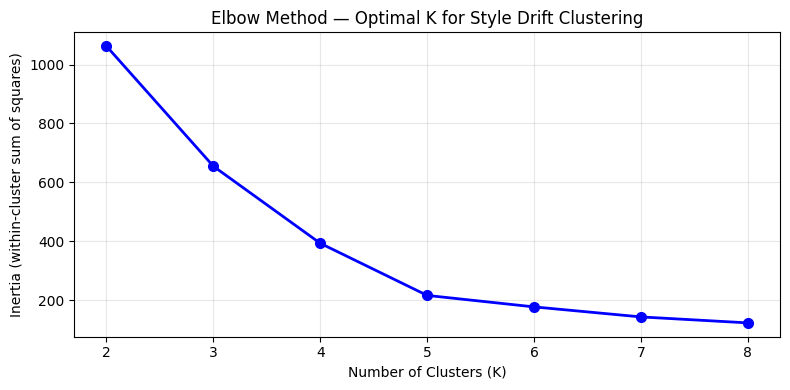

✓ Saved → outputs/elbow_plot.png


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ── Step 1: Isolate the 5 numeric features for clustering ────────────────────
FEATURES = ["pct_large_cap", "pct_mid_cap", "pct_small_cap",
            "top10_concentration", "sector_hhi"]

X = feature_matrix[FEATURES].values

# ── Step 2: Scale features ────────────────────────────────────────────────────
# K-Means uses distance — sector_hhi is in hundreds while pct columns are 0-100
# Without scaling, HHI would dominate. StandardScaler fixes this.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled feature matrix: {X_scaled.shape}")

# ── Step 3: Elbow method — find the right K ───────────────────────────────────
# We expect K=3 (large/mid/small) but let's confirm with data
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, "bo-", linewidth=2, markersize=7)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method — Optimal K for Style Drift Clustering")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/elbow_plot.png", dpi=150)
plt.show()
print("✓ Saved → outputs/elbow_plot.png")

In [6]:
# ── Run K-Means with K=5 ─────────────────────────────────────────────────────
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
feature_matrix["cluster"] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(feature_matrix["cluster"].value_counts().sort_index())

print("\nCluster vs Declared Category (how well do they align?):")
print(
    pd.crosstab(
        feature_matrix["declared_category"],
        feature_matrix["cluster"],
        margins=True
    )
)

Cluster distribution:
cluster
0     58
1    101
2    131
3     58
4      6
Name: count, dtype: int64

Cluster vs Declared Category (how well do they align?):
cluster             0    1    2   3  4  All
declared_category                          
Flexi Cap           0   43   15   0  1   59
Large & Mid Cap     0    0   58   0  1   59
Large Cap           0   58    0   0  1   59
Mid Cap            58    0    0   0  1   59
Multi Cap           0    0   58   0  1   59
Small Cap           0    0    0  58  1   59
All                58  101  131  58  6  354


Variance explained by PC1: 55.2%
Variance explained by PC2: 24.4%
Total variance captured:   79.6%


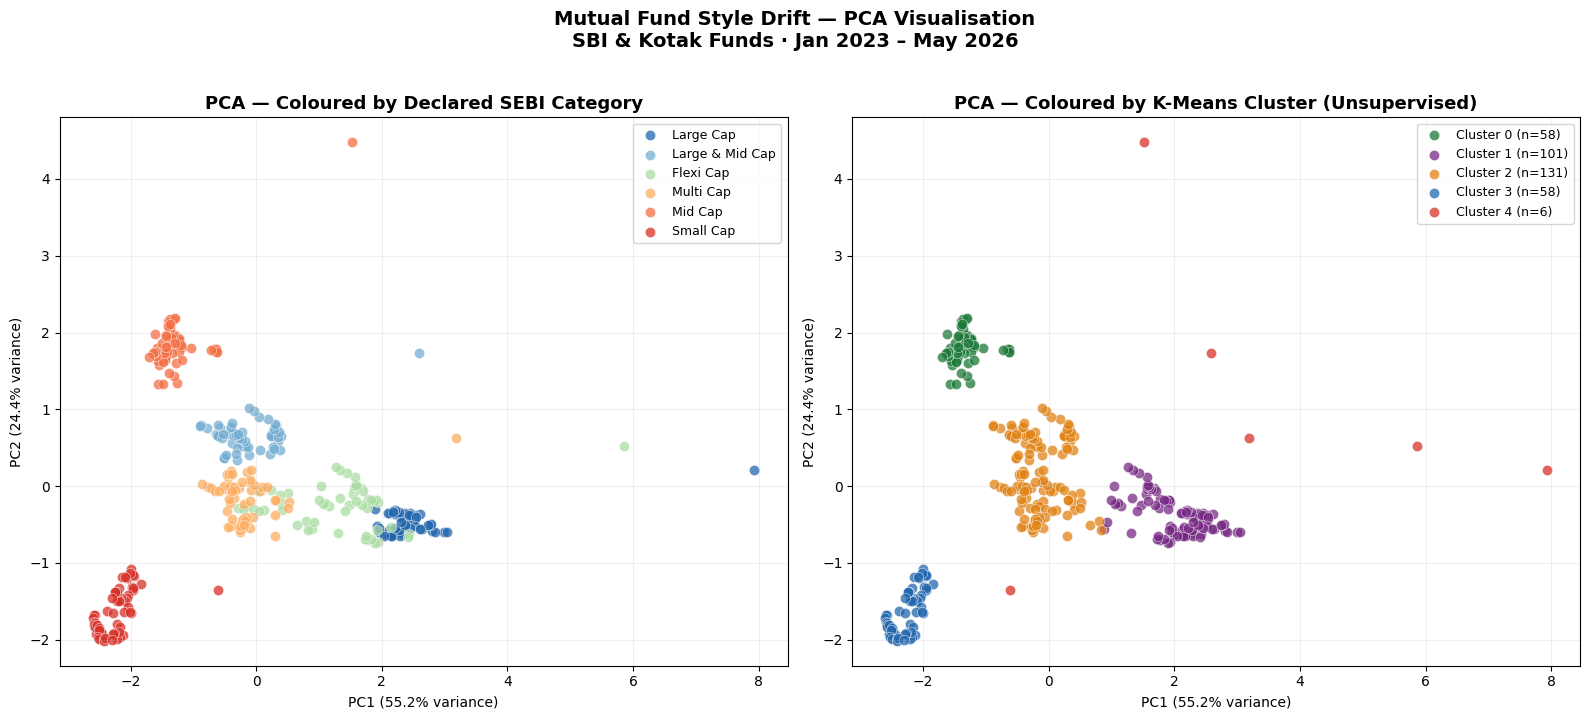

✓ Saved → outputs/pca_scatter.png


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── PCA: compress 5 features → 2 dimensions for visualisation ────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

feature_matrix["pca_x"] = X_pca[:, 0]
feature_matrix["pca_y"] = X_pca[:, 1]

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance captured:   {sum(pca.explained_variance_ratio_)*100:.1f}%")

# ── Plot: colour by DECLARED category (not cluster) ──────────────────────────
# This shows where each fund CLAIMS to be vs where it actually sits
category_colors = {
    "Large Cap":     "#2166ac",
    "Large & Mid Cap":"#74add1",
    "Flexi Cap":     "#abdda4",
    "Multi Cap":     "#fdae61",
    "Mid Cap":       "#f46d43",
    "Small Cap":     "#d73027",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left plot: coloured by declared category ──────────────────────────────────
ax1 = axes[0]
for cat, color in category_colors.items():
    mask = feature_matrix["declared_category"] == cat
    ax1.scatter(
        feature_matrix.loc[mask, "pca_x"],
        feature_matrix.loc[mask, "pca_y"],
        c=color, label=cat, alpha=0.75, s=55, edgecolors="white", linewidths=0.4
    )
ax1.set_title("PCA — Coloured by Declared SEBI Category", fontsize=13, fontweight="bold")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax1.legend(fontsize=9, loc="best")
ax1.grid(True, alpha=0.2)

# ── Right plot: coloured by K-Means cluster ───────────────────────────────────
ax2 = axes[1]
cluster_colors = ["#1b7837", "#762a83", "#e08214", "#2166ac", "#d73027"]
for cluster_id in sorted(feature_matrix["cluster"].unique()):
    mask = feature_matrix["cluster"] == cluster_id
    ax2.scatter(
        feature_matrix.loc[mask, "pca_x"],
        feature_matrix.loc[mask, "pca_y"],
        c=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id} (n={mask.sum()})",
        alpha=0.75, s=55, edgecolors="white", linewidths=0.4
    )
ax2.set_title("PCA — Coloured by K-Means Cluster (Unsupervised)", fontsize=13, fontweight="bold")
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax2.legend(fontsize=9, loc="best")
ax2.grid(True, alpha=0.2)

plt.suptitle("Mutual Fund Style Drift — PCA Visualisation\nSBI & Kotak Funds · Jan 2023 – May 2026",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → outputs/pca_scatter.png")

In [8]:
from scipy.spatial.distance import euclidean

# ── Step 1: Calculate each cluster's centroid in PCA space ───────────────────
centroids_pca = (
    feature_matrix.groupby("cluster")[["pca_x", "pca_y"]]
    .mean()
    .rename(columns={"pca_x": "centroid_x", "pca_y": "centroid_y"})
)
print("Cluster centroids in PCA space:")
print(centroids_pca.to_string())

# ── Step 2: For each fund-month, calculate distance from its cluster centroid ─
def dist_from_centroid(row):
    cx = centroids_pca.loc[row["cluster"], "centroid_x"]
    cy = centroids_pca.loc[row["cluster"], "centroid_y"]
    return euclidean([row["pca_x"], row["pca_y"]], [cx, cy])

feature_matrix["drift_score"] = feature_matrix.apply(dist_from_centroid, axis=1)

print(f"\nDrift score stats:")
print(feature_matrix.groupby("scheme_name")["drift_score"].agg(["mean","max","std"]).round(3).to_string())

Cluster centroids in PCA space:
         centroid_x  centroid_y
cluster                        
0         -1.323811    1.826096
1          2.030233   -0.397679
2         -0.139616    0.168844
3         -2.249268   -1.622174
4          3.412473    1.036588

Drift score stats:
                            mean    max    std
scheme_name                                   
Kotak Flexicap Fund        0.529  0.999  0.228
Kotak Large & Midcap Fund  0.707  0.846  0.068
Kotak Large Cap Fund       0.265  0.363  0.055
Kotak Midcap Fund          0.194  0.355  0.114
Kotak Multicap Fund        0.333  0.593  0.118
Kotak Small Cap Fund       0.275  0.541  0.129
SBI Flexicap Fund          0.672  2.501  0.415
SBI Large Cap Fund         0.543  4.595  0.698
SBI Large and Midcap Fund  0.550  1.082  0.199
SBI Midcap Fund            0.402  3.926  0.599
SBI MultiCap Fund          0.546  0.922  0.217
SBI Smallcap Fund          0.457  4.678  0.694


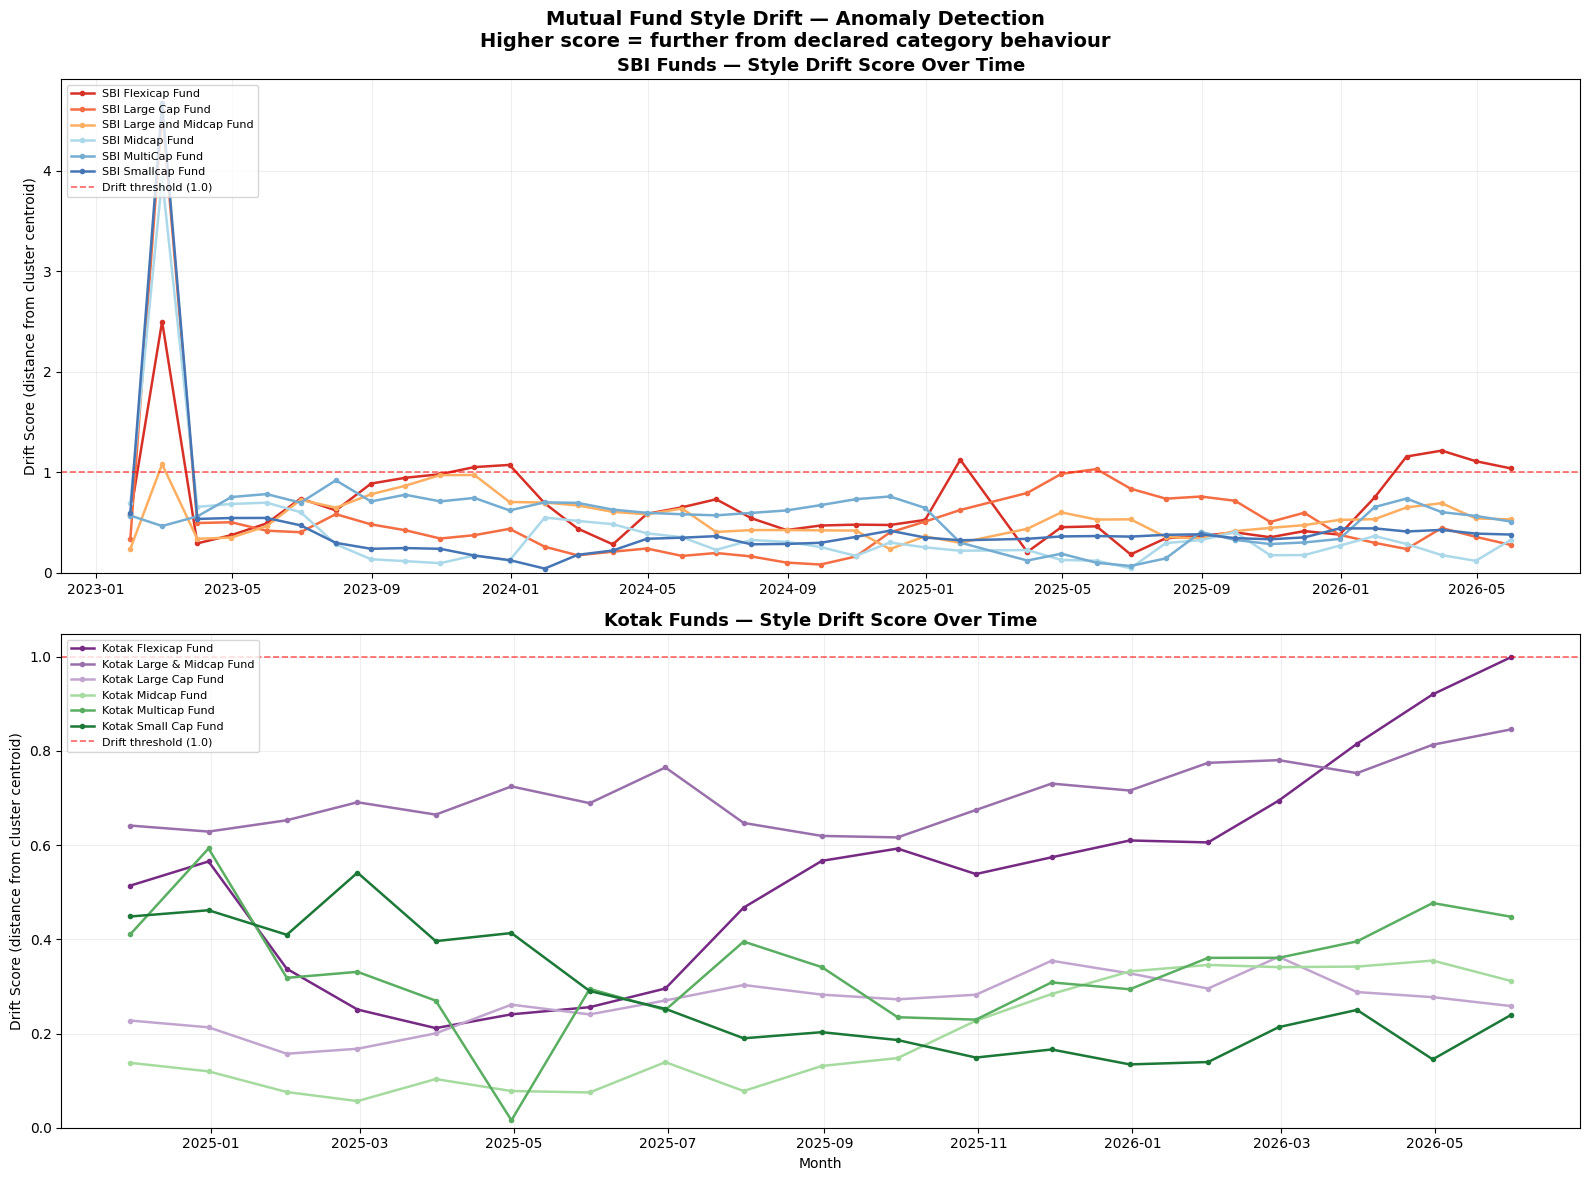


── Funds that crossed drift threshold of 1.0 ──
                           months_above_threshold  max_drift first_breach_date
scheme_name                                                                   
SBI Smallcap Fund                               1   4.677643        2023-02-28
SBI Large Cap Fund                              2   4.595439        2023-02-28
SBI Midcap Fund                                 1   3.925782        2023-02-28
SBI Flexicap Fund                               8   2.500916        2023-02-28
SBI Large and Midcap Fund                       1   1.081771        2023-02-28

✓ Saved → /content/drive/MyDrive/StyleDrift_Project/processed/feature_matrix_final.csv

Phase 3 complete. Project ready for GitHub.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Drift score over time per fund ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sbi_funds   = [f for f in feature_matrix["scheme_name"].unique() if "SBI" in f]
kotak_funds = [f for f in feature_matrix["scheme_name"].unique() if "Kotak" in f]

sbi_colors   = ["#d73027","#f46d43","#fdae61","#abd9e9","#74add1","#4575b4"]
kotak_colors = ["#762a83","#9970ab","#c2a5cf","#a6dba0","#5aae61","#1b7837"]

# ── Top plot: SBI funds ───────────────────────────────────────────────────────
ax1 = axes[0]
for i, fund in enumerate(sorted(sbi_funds)):
    df_fund = feature_matrix[feature_matrix["scheme_name"] == fund].sort_values("statement_date")
    ax1.plot(df_fund["statement_date"], df_fund["drift_score"],
             label=fund, color=sbi_colors[i], linewidth=1.8, marker="o", markersize=3)

ax1.axhline(y=1.0, color="red", linestyle="--", linewidth=1.2, alpha=0.6, label="Drift threshold (1.0)")
ax1.set_title("SBI Funds — Style Drift Score Over Time", fontsize=13, fontweight="bold")
ax1.set_ylabel("Drift Score (distance from cluster centroid)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.2)
ax1.set_ylim(bottom=0)

# ── Bottom plot: Kotak funds ──────────────────────────────────────────────────
ax2 = axes[1]
for i, fund in enumerate(sorted(kotak_funds)):
    df_fund = feature_matrix[feature_matrix["scheme_name"] == fund].sort_values("statement_date")
    ax2.plot(df_fund["statement_date"], df_fund["drift_score"],
             label=fund, color=kotak_colors[i], linewidth=1.8, marker="o", markersize=3)

ax2.axhline(y=1.0, color="red", linestyle="--", linewidth=1.2, alpha=0.6, label="Drift threshold (1.0)")
ax2.set_title("Kotak Funds — Style Drift Score Over Time", fontsize=13, fontweight="bold")
ax2.set_ylabel("Drift Score (distance from cluster centroid)")
ax2.set_xlabel("Month")
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(True, alpha=0.2)
ax2.set_ylim(bottom=0)

plt.suptitle("Mutual Fund Style Drift — Anomaly Detection\nHigher score = further from declared category behaviour",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/drift_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Flag funds that crossed the threshold ─────────────────────────────────────
print("\n── Funds that crossed drift threshold of 1.0 ──")
flagged = (
    feature_matrix[feature_matrix["drift_score"] > 1.0]
    .groupby("scheme_name")
    .agg(
        months_above_threshold = ("drift_score", "count"),
        max_drift              = ("drift_score", "max"),
        first_breach_date      = ("statement_date", "min")
    )
    .sort_values("max_drift", ascending=False)
)
print(flagged.to_string())

# ── Save final enriched matrix ────────────────────────────────────────────────
feature_matrix.to_csv(f"{BASE}/processed/feature_matrix_final.csv", index=False)
print(f"\n✓ Saved → {BASE}/processed/feature_matrix_final.csv")
print("\nPhase 3 complete. Project ready for GitHub.")